## Task 1: Data Understanding

In [3]:
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python

!unzip -o customer-segmentation-tutorial-in-python.zip

print("\nDataset successfully downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
100% 1.55k/1.55k [00:00<00:00, 4.01MB/s]

Archive:  customer-segmentation-tutorial-in-python.zip
  inflating: Mall_Customers.csv      

Dataset successfully downloaded and extracted!


## Task 1: Data Understanding

In [4]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')

print("First five records of the dataset:")
display(df.head())

print("\nNumerical Features: Age, Annual Income (k$), Spending Score (1-100)")
print("Categorical Features: Gender")

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe(include='all'))

First five records of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Numerical Features: Age, Annual Income (k$), Spending Score (1-100)
Categorical Features: Gender

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Summary Statistics:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## Task 2: Data Preprocessing

In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Missing values in each column:\n", df.isnull().sum())

df = df.drop(columns=['CustomerID'])

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled_features, columns=df.columns)
print("\nData preprocessing complete. Scaled data preview:")
display(df_scaled.head())

Missing values in each column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data preprocessing complete. Scaled data preview:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


## Task 3: Model Development

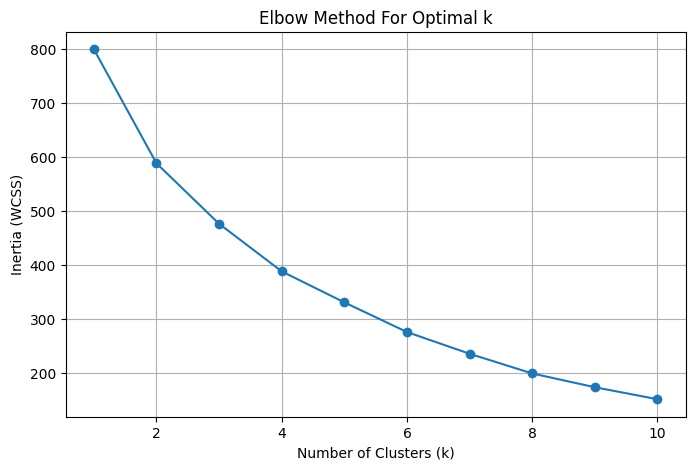

Model development and PCA transformation complete.


In [6]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_model.fit(df_scaled)

df['Cluster'] = kmeans_model.labels_

pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

print("Model development and PCA transformation complete.")

## Task 4: Visualization and Evaluation

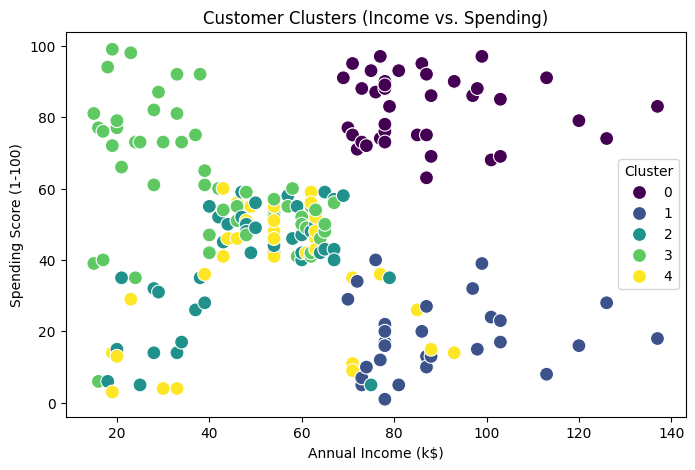

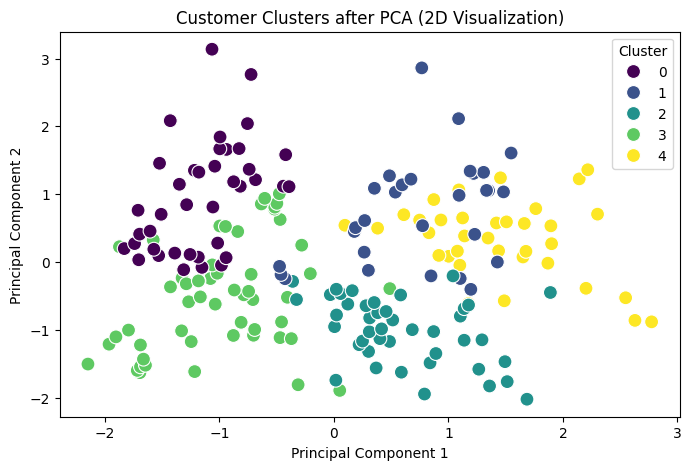

In [7]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'],
                hue=df['Cluster'], palette='viridis', s=100)
plt.title('Customer Clusters (Income vs. Spending)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'],
                hue=df_pca['Cluster'], palette='viridis', s=100)
plt.title('Customer Clusters after PCA (2D Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### Observations:
1. **Optimal Number of Clusters:** The Elbow Curve shows a distinct "elbow" or inflection point at $k=5$, indicating that 5 clusters optimally balance minimizing inertia without overfitting the data.
2. **Role of PCA:** PCA helps visualize high-dimensional data (Age, Gender, Income, Spending) by condensing the variance into just two principal components, allowing us to plot the distinct cluster separations on a standard 2D scatter plot.
3. **Cluster Characteristics:** Looking at the Income vs. Spending plot, the five distinct groups typically represent:
   - High Income, High Spending (Target group)
   - High Income, Low Spending (Careful spenders)
   - Low Income, High Spending (Careless spenders)
   - Low Income, Low Spending (Sensible spenders)
   - Average Income, Average Spending (Standard consumers)

## Task 5: Conclusion

# Conclusion

The K-Means clustering algorithm successfully segmented the mall customers into five distinct groups based on their annual income and spending behavior. These key findings reveal clear behavioral patterns, such as high-income/high-spending and low-income/low-spending groups. From a business perspective, these customer segments are highly valuable for targeted marketing campaigns. For instance, management can deploy exclusive loyalty programs for the most profitable group or offer specific discounts to budget-conscious shoppers.

While K-Means is highly efficient, one notable limitation is that it requires the optimal number of clusters (K) to be manually defined beforehand and can be sensitive to outliers. Conversely, applying Principal Component Analysis (PCA) provided a significant advantage by reducing the computational complexity and dimensionality of the dataset. This allowed us to effectively visualize the complex customer clusters on a 2D plane while preserving the most critical patterns in the data.